In [23]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics
import yfinance as yf
import tensorflow as tf

from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.python.keras.utils import np_utils
from keras.datasets import mnist
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from prophet.plot import add_changepoints_to_plot, plot_plotly, plot_components_plotly
from prophet  import Prophet
from openpyxl import load_workbook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, silhouette_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier



# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

# 강아지 품종 분류예측

## 1. 품종별 강아지 이미지 수집

* data/dog/      말티즈, 요크셔, 푸들

## 2. 데이터 불러오기 및 탐색

In [24]:
import glob
root_dir = "../../data/dog/"

In [25]:
categories = ["말티즈", "요크셔", "푸들"]
num_class = len(categories)

In [26]:
## 이미지 크기 설정
image_width = 64
image_height = 64

In [27]:
## 파일 불러오기

X = [] # 이미지 저장 리스트
Y = [] # 이미지의 카테고리 인덱스 저장 리스트

for idx, category in enumerate(categories):
    image_dir = root_dir + category
    files = glob.glob(image_dir + "/*.*")      

    for i, f in enumerate(files):                
        img = Image.open(f)
        img = img.convert("RGB")
        img = img.resize((image_width, image_height))
        data = np.asarray(img)
        X.append(data)
        Y.append(idx)        
        
    print(f"{image_dir} : {i+1}")

../../data/dog/말티즈 : 10
../../data/dog/요크셔 : 6
../../data/dog/푸들 : 5


In [28]:
print("X 데이터 총 개수 :", len(X)) #이미지 파일의 총 개수
print("Y 데이터 총 개수 :", len(Y))  #이미지 파일의 총 개수

X 데이터 총 개수 : 21
Y 데이터 총 개수 : 21


In [ ]:
## 데이터 형태를 배열로 변환하기

np_x = np.array(X)
np_y = np.array(Y)

print(np_x.shape)   # 21개의 이미지가 64x64 크기로 RGB 형태로 들어있다.
print(np_y.shape)

(21, 64, 64, 3)
(21,)


In [34]:
## 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(np_x, np_y, test_size=0.2, random_state=42)

In [35]:
## 정규화
X_train = X_train.astype("float") / 255
X_test = X_test.astype("float") / 255

In [36]:
## 카테고리
Y_train = np_utils.to_categorical(Y_train, num_class)
Y_test = np_utils.to_categorical(Y_test, num_class)

## 3. CNN 모델 구축 _ 품종 분류 모델 구축 및 학습

In [37]:
# 입력 이미지의 크기 및 색상채널 수 설정
input_shape = (image_width, image_height, 3)  # 가로 64, 세로 64, 3개의 채널(RGB)

In [38]:
model = Sequential([
    Input(shape=(64, 64, 3)),  # 64X64 크기의 컬러 이미지 (RGB, 3개 채널)
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),  
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)), 
    Flatten(),  
    Dense(512, activation='relu'),  
    Dense(num_class, activation='softmax') 
])

In [39]:
from keras.metrics import Precision
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy", Precision()])

In [45]:
### 모델학습
model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=30, batch_size=5, verbose=1)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 1.0000 - loss: 2.2426e-06 - precision: 1.0000 - val_accuracy: 0.8000 - val_loss: 1.3539 - val_precision: 0.8000
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 1.0000 - loss: 2.2203e-06 - precision: 1.0000 - val_accuracy: 0.8000 - val_loss: 1.3547 - val_precision: 0.8000
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 2.1830e-06 - precision: 1.0000 - val_accuracy: 0.8000 - val_loss: 1.3541 - val_precision: 0.8000
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 1.0000 - loss: 2.1532e-06 - precision: 1.0000 - val_accuracy: 0.8000 - val_loss: 1.3476 - val_precision: 0.8000
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 1.0000 - loss: 2.1011e-06 - precision: 1.0000 - val_accuracy: 0.8000 - val_loss: 1.3432 - val_precision: 0.8000
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 1.0000 - loss: 2.1011e-06 - precision: 1.0000 - val_accuracy: 0.8000 -

In [46]:
### 모델 평가
score = model.evaluate(X_test, Y_test)
print('loss =', score[0])
print('accuracy =', score[1])
print('precision =', score[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8000 - loss: 1.3668 - precision: 0.8000
loss = 1.366817831993103
accuracy = 0.800000011920929
precision = 0.800000011920929


## 4. 새로운 데이터로 예측하기

In [47]:
#### 새로운 이미지 데이터

new_files = glob.glob(root_dir+"new/*.*")
new_files

['../../data/dog/new/new1.jpg',
 '../../data/dog/new/new2.jpg',
 '../../data/dog/new/new3.jpg']

In [48]:
#### 새로운 이미지를 CNN모델의 입력 형태로 만들기

image_size = 64
new_img = []
new_X = []

# 이미지 불러오기
for i,fname in enumerate(new_files):
    img = Image.open(fname)
    img = img.convert("RGB")
    img = img.resize((image_size, image_size))
    new_img.append(img) 
    new_data = np.asarray(img)
    new_data = new_data.astype("float") / 255 
    new_X.append(new_data) 

new_X = np.array(new_X)

In [49]:
#### 예측 수행
new_Predict = model.predict(new_X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step


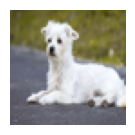

입력:../../data/dog/new/new1.jpg => 예측: 말티즈 / Score=99.96%




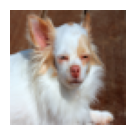

입력:../../data/dog/new/new2.jpg => 예측: 말티즈 / Score=99.91%




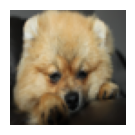

입력:../../data/dog/new/new3.jpg => 예측: 요크셔 / Score=97.67%




In [50]:
#### 예측 결과 출력
for i, c in enumerate(new_Predict):
    plt.figure(figsize=(1.5,1.5))
    plt.imshow(new_img[i])
    plt.axis('off')
    plt.show()

    top_1 = c.argmax()
    if c[top_1] > 0.78:                
        print(f"입력:{new_files[i]} => 예측: {categories[top_1]} / Score={c[top_1]*100:.2f}%\n\n")
    else :               
        top_2 = np.argsort(c)[-2]
        print(f"입력:{new_files[i]} => 예측: {categories[top_1]}({c[top_1]*100:.2f}%) 와 {categories[top_2]}({c[top_2]*100:.2f}%)의 믹스견으로 추정됩니다.\n\n")